**Assingment Lecture 4**
Submit the following exercises from 3.7 as a Google Colab links:
3 a-c, 8.a, 10 a-f, & 14 a-g

3. Suppose we have a data set with fve predictors, X1 = GPA, X2 =
IQ, X3 = Level (1 for College and 0 for High School), X4 = Interaction between GPA and IQ, and X5 = Interaction between GPA and
Level. The response is starting salary after graduation (in thousands
of dollars). Suppose we use least squares to ft the model, and get
βˆ0 = 50, βˆ1 = 20, βˆ2 = 0.07, βˆ3 = 35, βˆ4 = 0.01, βˆ5 = −10.
(a) Which answer is correct, and why?

Ans 3 a : (iii) For a fxed value of IQ and GPA, high school graduates earn
more, on average, than college graduates provided that the
GPA is high enough.

Ans 3 (b) Predict the salary of a college graduate with IQ of 110 and a GPA of 4.0.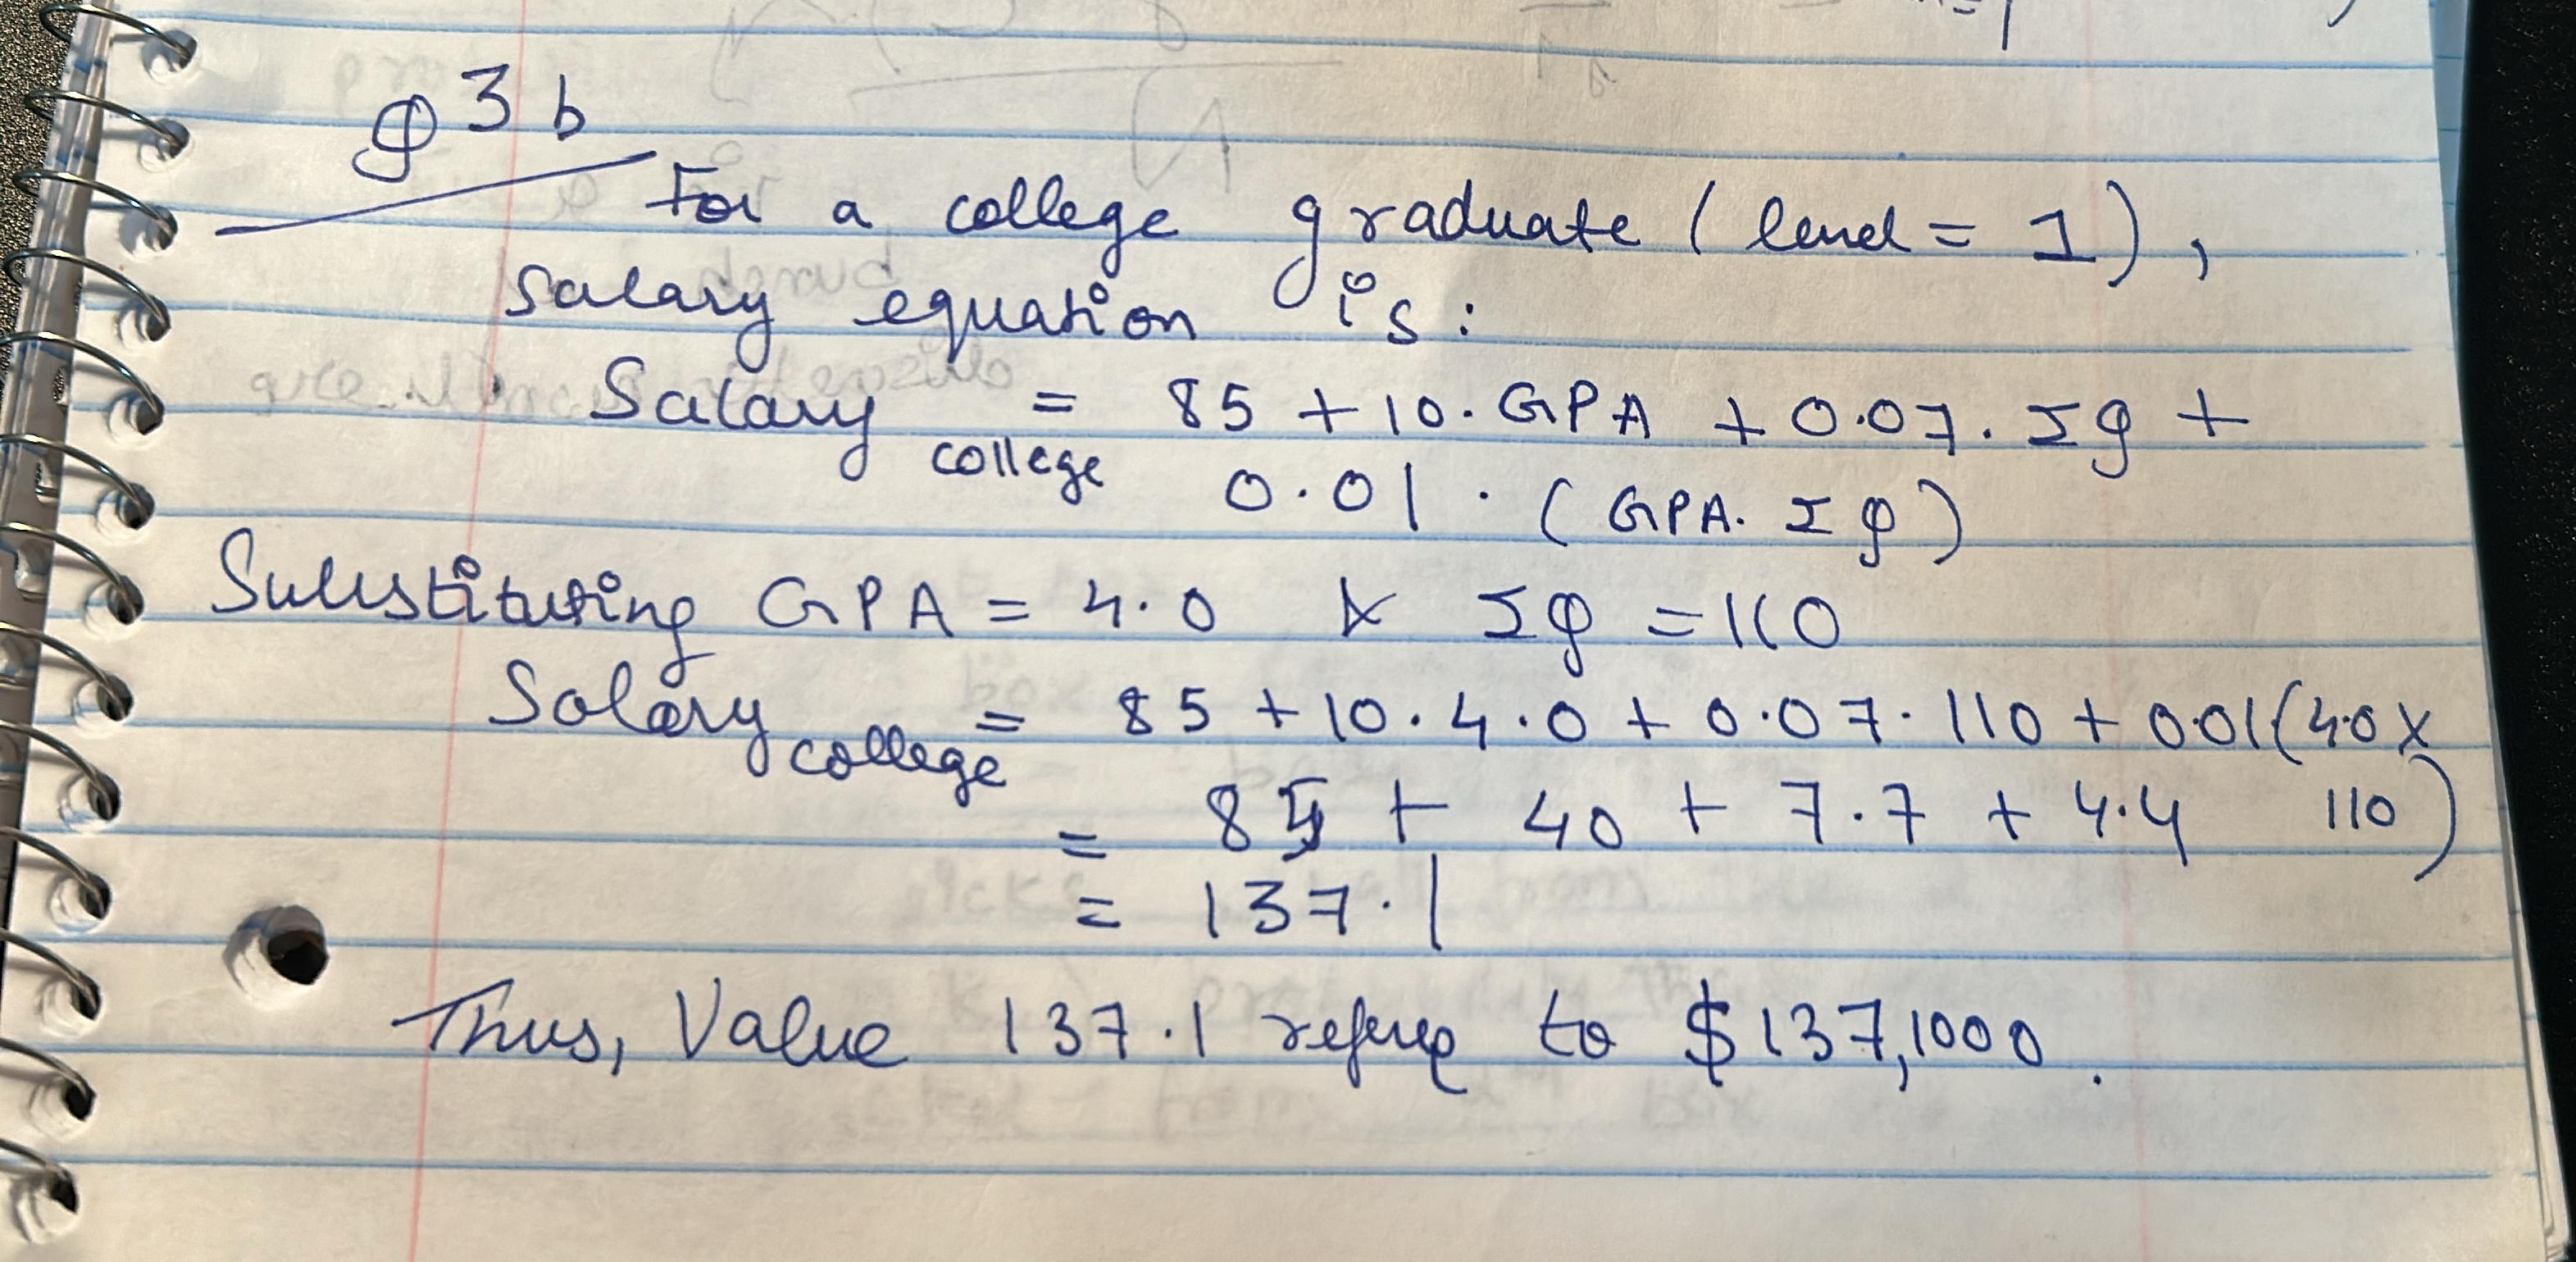

3-c : False: the interaction effect might be small but we would need to inspect the standard error to understand if this interaction effect is significant. If the standard error is also very small then it might still be considered a significant effect.The coefficient for the GPA/IQ interaction term is 𝛽4=0.01
,which is indeed small. However, just because the coefficient is small does not necessarily mean that the interaction effect is negligible in practice.The interaction term 0.01⋅GPA⋅IQ may still have a noticeable effect for higher values of GPA and IQ, even though the coefficient is small.
To properly assess whether there is strong evidence for the interaction effect, we would need additional statistical information, such as the p-value for the interaction term. A small coefficient could still be statistically significant if the p-value is low.
So, based on the information given, the answer is False. Even though the interaction coefficient is small, this does not automatically imply that there is no interaction effect.



## **Ques 8 A ans :**

In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset directly from the URL
url = 'https://www.statlearning.com/s/Auto.csv'
df = pd.read_csv(url)

# Step 2: Clean the data (handle missing values and convert horsepower to numeric)
df = df.dropna()
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df = df.dropna(subset=['horsepower'])

# Check the dataset structure
print(df.info())  # Print to ensure no missing values in horsepower or mpg
# Set the predictor (X) and response (y)
X = df['horsepower']
y = df['mpg']
# Add a constant term to the predictor for the intercept
X = sm.add_constant(X)
model = sm.OLS(y, X)
results = model.fit()
# Print the summary of the regression model
print(results.summary())

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
 8   name          392 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 30.6+ KB
None
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Fri, 27 Sep 2024   Prob

In [ ]:
# Print the p-value of the horsepower coefficient
p_value = results.pvalues['horsepower']
print(f"\nIs there a relationship between horsepower and mpg?")

# Typically, a p-value < 0.05 indicates a statistically significant relationship
if p_value < 0.05:
    print(f"Yes, there is a relationship. (p-value = {p_value})")
else:
    print(f"No, there is no significant relationship. (p-value = {p_value})")



Is there a relationship between horsepower and mpg?
Yes, there is a relationship. (p-value = 7.031989029405063e-81)


In [ ]:
# Print the R-squared value
r_squared = results.rsquared
print(f"\nHow strong is the relationship between horsepower and mpg?")
print(f"The R-squared value is {r_squared:.3f}, which means approximately {r_squared*100:.2f}% of the variance in mpg is explained by horsepower.")



How strong is the relationship between horsepower and mpg?
The R-squared value is 0.606, which means approximately 60.59% of the variance in mpg is explained by horsepower.


In [ ]:
# Print the coefficient of horsepower
hp_coef = results.params['horsepower']
print(f"\nIs the relationship between horsepower and mpg positive or negative?")
if hp_coef < 0:
    print(f"The relationship is negative. (Coefficient = {hp_coef})")
else:
    print(f"The relationship is positive. (Coefficient = {hp_coef})")



Is the relationship between horsepower and mpg positive or negative?
The relationship is negative. (Coefficient = -0.15784473335365357)


In [ ]:
# Define the horsepower value for prediction
hp_value = 98

# Prepare the new data for prediction (with constant term)
# Make sure to match the shape of X used in the model
new_X = pd.DataFrame({'const': [1], 'horsepower': [hp_value]})

# Get the prediction result for mpg
prediction = results.get_prediction(new_X)

# Predicted mpg
pred_mpg = prediction.predicted_mean[0]
print(f"\nThe predicted mpg for a horsepower of 98 is {pred_mpg:.2f}")

# 95% confidence interval
conf_int = prediction.conf_int()
print(f"\nThe 95% confidence interval for mpg is {conf_int[0]}")

# 95% prediction interval (for an individual prediction)
pred_interval = prediction.summary_frame(alpha=0.05)
print(f"The 95% prediction interval for mpg is {pred_interval[['obs_ci_lower', 'obs_ci_upper']].iloc[0]}")


The predicted mpg for a horsepower of 98 is 24.47

The 95% confidence interval for mpg is [23.97307896 24.96107534]
The 95% prediction interval for mpg is obs_ci_lower    14.809396
obs_ci_upper    34.124758
Name: 0, dtype: float64


## **Q10 - A - F solutions : This question should be answered using the Carseats data set**

In [ ]:
# Import necessary libraries
from google.colab import drive
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Mount Google Drive to access the Carseats data
drive.mount('/content/drive')

# Load the Carseats data from your drive (update path if necessary)
file_path = '/content/drive/MyDrive/DATA602/Carseats.csv'  # Updated path
df = pd.read_csv(file_path)

# Ensure all relevant columns are correctly formatted
# Check the types of each column
print("Data types of each column before conversion:")
print(df.dtypes)

# Convert Price and Sales to numeric (if needed)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')

# Convert categorical variables 'Urban', 'US', and 'ShelveLoc' into dummy variables
df = pd.get_dummies(df, columns=['Urban', 'US', 'ShelveLoc'], drop_first=True)

# Ensure no missing values (caused by coercion)
df = df.dropna()

# Verify data types again after conversion
print("\nData types of each column after conversion:")
print(df.dtypes)

# Check for any remaining object types
if df.select_dtypes(include='object').shape[1] > 0:
    print("Warning: Some columns are still of type object.")
else:
    print("All columns are now numeric or boolean.")

# Convert boolean columns to integers (0 and 1) to avoid errors in statsmodels
df['Urban_Yes'] = df['Urban_Yes'].astype(int)
df['US_Yes'] = df['US_Yes'].astype(int)
df['ShelveLoc_Good'] = df['ShelveLoc_Good'].astype(int)
df['ShelveLoc_Medium'] = df['ShelveLoc_Medium'].astype(int)

# (a) Fit the multiple regression model using Price, Urban_Yes, and US_Yes as predictors
X = df[['Price', 'Urban_Yes', 'US_Yes']]  # Add other variables as needed
y = df['Sales']

# Ensure that all data in X and y are numeric
X = X.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')

# Add a constant term (intercept)
X = sm.add_constant(X)

# Fit the model using OLS
model = sm.OLS(y, X).fit()

# (a) Print the summary of the regression to answer the question
print("(a) Fit a multiple regression model to predict Sales using Price, Urban, and US:\n")
print(model.summary())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data types of each column before conversion:
Sales          float64
CompPrice        int64
Income           int64
Advertising      int64
Population       int64
Price            int64
ShelveLoc       object
Age              int64
Education        int64
Urban           object
US              object
dtype: object

Data types of each column after conversion:
Sales               float64
CompPrice             int64
Income                int64
Advertising           int64
Population            int64
Price                 int64
Age                   int64
Education             int64
Urban_Yes              bool
US_Yes                 bool
ShelveLoc_Good         bool
ShelveLoc_Medium       bool
dtype: object
All columns are now numeric or boolean.
(a) Fit a multiple regression model to predict Sales using Price, Urban, and US:

                            OLS Regression

In [ ]:
# (b) Interpretation of each coefficient

print("\n(b) Interpretation of each coefficient:\n")

# Coefficients from the model
coefficients = model.params
print(f"Intercept (β0): {coefficients['const']:.2f}")
print(f"Price (β1): {coefficients['Price']:.2f}")
print(f"Urban_Yes (β2): {coefficients['Urban_Yes']:.2f}")
print(f"US_Yes (β3): {coefficients['US_Yes']:.2f}")

# Interpretation of coefficients
print("\nInterpretation:")
print(f"1. The Intercept (β0 = {coefficients['const']:.2f}) is the baseline sales when Price, Urban, and US are all zero.")
print(f"2. The Price coefficient (β1 = {coefficients['Price']:.2f}) means that for each 1 unit increase in Price, Sales decrease by {abs(coefficients['Price']):.2f} units, holding all other variables constant.")
print(f"3. The Urban_Yes coefficient (β2 = {coefficients['Urban_Yes']:.2f}) indicates that sales for stores in urban areas are {coefficients['Urban_Yes']:.2f} units lower compared to non-urban stores, holding all else constant.")
print(f"4. The US_Yes coefficient (β3 = {coefficients['US_Yes']:.2f}) indicates that sales for stores in the US are {coefficients['US_Yes']:.2f} units higher compared to stores outside the US, holding all else constant.")



(b) Interpretation of each coefficient:

Intercept (β0): 13.04
Price (β1): -0.05
Urban_Yes (β2): -0.02
US_Yes (β3): 1.20

Interpretation:
1. The Intercept (β0 = 13.04) is the baseline sales when Price, Urban, and US are all zero.
2. The Price coefficient (β1 = -0.05) means that for each 1 unit increase in Price, Sales decrease by 0.05 units, holding all other variables constant.
3. The Urban_Yes coefficient (β2 = -0.02) indicates that sales for stores in urban areas are -0.02 units lower compared to non-urban stores, holding all else constant.
4. The US_Yes coefficient (β3 = 1.20) indicates that sales for stores in the US are 1.20 units higher compared to stores outside the US, holding all else constant.


In [ ]:
# (c) Write out the model in equation form

print("\n(c) Model in equation form:\n")
print(f"Sales = {coefficients['const']:.2f} + ({coefficients['Price']:.2f} * Price) + ({coefficients['Urban_Yes']:.2f} * Urban_Yes) + ({coefficients['US_Yes']:.2f} * US_Yes)")



(c) Model in equation form:

Sales = 13.04 + (-0.05 * Price) + (-0.02 * Urban_Yes) + (1.20 * US_Yes)


In [ ]:
# (d) For which predictors can you reject the null hypothesis H0: βj = 0?

print("\n(d) For which predictors can you reject the null hypothesis H0: βj = 0?\n")

# Print p-values
print(model.pvalues)
# Identify predictors with p-value < 0.05
significant_predictors = model.pvalues[model.pvalues < 0.05].index.tolist()
print(f"Predictors where we reject H0 (p-value < 0.05): {significant_predictors}")


(d) For which predictors can you reject the null hypothesis H0: βj = 0?

const        3.626602e-62
Price        1.609917e-22
Urban_Yes    9.357389e-01
US_Yes       4.860245e-06
dtype: float64
Predictors where we reject H0 (p-value < 0.05): ['const', 'Price', 'US_Yes']


Conclusion:
Price and US_Yes have p-values smaller than 0.05, so we reject the null hypothesis for these variables, indicating that they have a significant effect on Sales.
Urban_Yes has a p-value larger than 0.05, so we fail to reject the null hypothesis for it, meaning it likely does not significantly affect Sales.

In [ ]:
# (e) Fit a smaller model using only significant predictors (Price and US_Yes)

print("\n(e) Fit a smaller model using only significant predictors (Price and US_Yes):\n")

# Subset the data to only include significant predictors
X_small = df[['Price', 'US_Yes']]
X_small = sm.add_constant(X_small)

# Fit the smaller model
model_small = sm.OLS(y, X_small).fit()

# Print the summary of the smaller model
print(model_small.summary())


(e) Fit a smaller model using only significant predictors (Price and US_Yes):

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     62.43
Date:                Fri, 27 Sep 2024   Prob (F-statistic):           2.66e-24
Time:                        03:21:13   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1861.
Df Residuals:                     397   BIC:                             1873.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------

In [ ]:
# (f) Compare the fit of the models in (a) and (e)

print("\n(f) Compare the fit of the models in (a) and (e):\n")

# Print R-squared values for both models
print(f"Full model R-squared: {model.rsquared:.3f}")
print(f"Smaller model R-squared: {model_small.rsquared:.3f}")

# Print Adjusted R-squared values for both models
print(f"Full model Adjusted R-squared: {model.rsquared_adj:.3f}")
print(f"Smaller model Adjusted R-squared: {model_small.rsquared_adj:.3f}")
# Analyse residuals
lm_plot(lm_stats(X, y, y_pred))


(f) Compare the fit of the models in (a) and (e):

Full model R-squared: 0.239
Smaller model R-squared: 0.239
Full model Adjusted R-squared: 0.234
Smaller model Adjusted R-squared: 0.235


The R-squared value of the model in (a) is 0.239, and the R-squared value of the model in (e) is also 0.239. Thus, both models fit the data equally well.

### **Question 14(a) Run the provided code**

In [ ]:
# The code provided in the question
rng = np.random.default_rng(10)
x1 = rng.uniform(0, 1, size=100)
x2 = 0.5 * x1 + rng.normal(size=100) / 10
y = 2 + 2 * x1 + 0.3 * x2 + rng.normal(size=100)

### Q (a): The last line corresponds to creating a linear model in which y is a function of x1 and x2. Write out the form of the linear model. What are the regression coefcients?

=> The Linear model is of the form

$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \epsilon_0$

Where,

- $\beta_0$ is the intercept term, equal to 2
- $\beta_1$ is the coefficient of $X_1$, equal to 2
- $\beta_2$ is the coefficient of $X_2$, equal to 0.3
- $\epsilon_0$ is the error term which is sampled as $\epsilon_0 \sim N(0, 1)$

Thus, the correlation coefficients are $\beta_0 = 2$, $\beta_1 = 2$, and $\beta_2 = 0.3$

### (b) What is the correlation between x1 and x2? Create a scatterplot displaying the relationship between the variables.


#### Calculating the theoretical correlation between x1 and x2:
The relationship between x1 and x2 is:

$ x2 = 0.5 * x1 + \epsilon_1 $

Where,
- $\epsilon_1$ is the error term which is sampled as $\epsilon_1 \sim N(0, 0.01)$

The correlation between them can be found using the formula:

$Corr(X_1, X_2) = \frac{Cov(X_1, X_2)}{StdDev(X_1) \times StdDev(X_2)}$

and

$Cov(X_1, X_2) = Cov(X_1, 0.5X_1 + \frac{\epsilon_1}{10})$

= $Cov(X_1, 0.5X_1) + Cov(X_1, \frac{\epsilon_1}{10})$

= $0.5Var(X_1) + 0$

= $0.5Var(X_1)$

Thus,

$Corr(X_1, X_2) = \frac{0.5Var(X_1)}{StdDev(X_1) \times StdDev(X_2)}$               -- Eqn (1)

As $X_1$ is uniformly distributed, $Var(X_1) ~ 1/12$

And, $StdDev(X_1) = \sqrt{Var(X_1)} = \sqrt{1/12}$

And, $Var(X_2) = 0.5^2Var(X_1) + Var(\epsilon_1) = frac{1}{48} + 0.01$

Thus, from Eqn (1),

$Corr(X_1, X_2) = \frac{0.5/12}{StdDev(X_1) \times StdDev(X_2)}$

Thus, the theoretical correlation between x1 and x2 is

$Corr(X_1, X_2) = \frac{0.5/12}{\sqrt{1/12} \times \sqrt{1/48 + 0.01}}$

= ~ 0.822

#### Calculating the actual correlation between x1 and x2 in our case:

The correlation between x1 and x2 practically is 0.7885401505837345


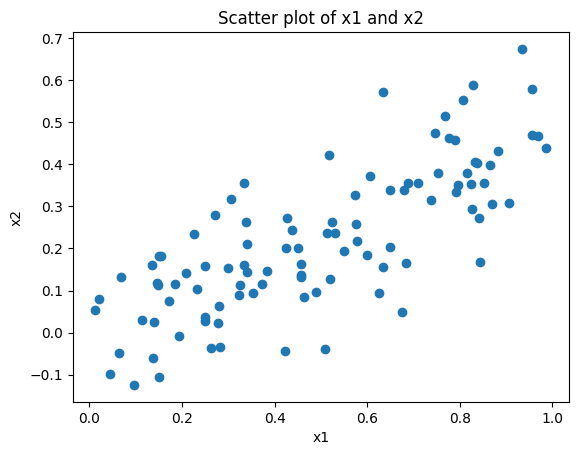

In [ ]:
# We can thus calculate the correlation between x1 and x2 as follows (from equation 1 above)

correlation = (0.5 * np.var(x1)) / (np.std(x1) * np.std(x2))
print(f"The correlation between x1 and x2 practically is {correlation}")

# Creating scatter plot

plt.scatter(x1, x2)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Scatter plot of x1 and x2')
plt.show()

### (c) Using this data, fit a least squares regression to predict y using x1 and x2. Describe the results obtained. What are βˆ0, βˆ1, and βˆ2? How do these relate to the true β0, β1, and β2? Can you reject the null hypothesis H0 : β1 = 0? How about the null hypothesis H0 : β2 = 0?

#### Solution:

Lets fit the linear model:

In [ ]:
X = pd.DataFrame({'x1': x1, 'x2': x2})
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.291
Model:                            OLS   Adj. R-squared:                  0.276
Method:                 Least Squares   F-statistic:                     19.89
Date:                Fri, 27 Sep 2024   Prob (F-statistic):           5.76e-08
Time:                        03:34:54   Log-Likelihood:                -130.62
No. Observations:                 100   AIC:                             267.2
Df Residuals:                      97   BIC:                             275.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.9579      0.190     10.319      0.0

#### Results:

The model is of the form:

$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2$

where,
- $\beta_0$ is the intercept term, equal to 1.9579
- $\beta_1$ is the coefficient of $X_1$, equal to 1.6154
- $\beta_2$ is the coefficient of $X_2$, equal to 0.9428

Thus, the estimated coefficients are $\beta_0 = 1.9579$, $\beta_1 = 1.6154$, and $\beta_2 = 0.9428$

Comparing the estimated coefficients with the true coefficients i.e, $\beta_0 = 2$, $\beta_1 = 2$, and $\beta_2 = 0.3$, we can see that the estimated coefficients are although on the similar scales, and maybe even close (for $\beta_0, and \beta_1$), but they are not exactly the same as the true coefficients. This is because of the non determinism and randomness in the data.

#### Hypothesis Testing:

Given the p-values of the predictors:
- $\beta_1$: 0.003, thus we can reject the null hypothesis $H_0: \beta_1 = 0$
- $\beta_2$: 0.259, thus we fail to reject the null hypothesis $H_0: \beta_2 = 0$


### (d) Now fit a least squares regression to predict y using only x1. Comment on your results. Can you reject the null hypothesis H0 : β1 = 0?

#### Solution:

In [ ]:
X = pd.DataFrame({'x1': x1})
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.281
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     38.39
Date:                Fri, 27 Sep 2024   Prob (F-statistic):           1.37e-08
Time:                        03:36:36   Log-Likelihood:                -131.28
No. Observations:                 100   AIC:                             266.6
Df Residuals:                      98   BIC:                             271.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.9371      0.189     10.242      0.0

Based on the results, the coefficient of x1 is 2.1707, and the p-value is 0.000, thus we can reject the null hypothesis $H_0: \beta_1 = 0$

It also makes sense as x1 is the only true predictor, and thus it has a strong relationship with y, and infact x2 is derived from x1 with some noise, x1 is enough to predict y.

### (e) Now fit a least squares regression to predict y using only x2. Comment on your results. Can you reject the null hypothesis H0 : β1 = 0?

#### Solution:

In [ ]:
X = pd.DataFrame({'x2': x2})
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.222
Model:                            OLS   Adj. R-squared:                  0.214
Method:                 Least Squares   F-statistic:                     27.99
Date:                Fri, 27 Sep 2024   Prob (F-statistic):           7.43e-07
Time:                        03:38:03   Log-Likelihood:                -135.24
No. Observations:                 100   AIC:                             274.5
Df Residuals:                      98   BIC:                             279.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.3239      0.154     15.124      0.0

Based on the results, the coefficient of x2 is 2.9103, and the p-value is 0.000, thus we can reject the null hypothesis $H_0: \beta_1 = 0$

It also makes sense as y is generated from x1 and x2, and x2 is derived from x1 with some noise, and thus y and x2 are strongly related.

### (f) Do the results obtained in (c)–(e) contradict each other? Explain your answer.

The results in (c) and (e) both suggest that y and x2 are strongly correlated (which is true), but although it seemed that we couldn't reject the null hypothesis $H_0: \beta_2 = 0$ in (c), and that we can reject the null hypothesis $H_0: \beta_1 = 0$ in (e), a contradiction still isn't necessarily present.
Our data has very less samples (only 100), and doing hypothesis testing on such a small dataset can lead to incorrect results.
Moreover, the fact that we can't reject the null hypothesis $H_0: \beta_2 = 0$ in (c) doesn't mean that the opposite is also true, and the same goes for (e).

Thus, the results in (c) and (e) don't necessarily contradict each other.

### (g) ==>

In [ ]:
# Suppose we obtain one additional observation, which was unfortunately mismeasured.
# We use the function np.concatenate() to np.concaadd this additional observation to each of x1, x2 and y. tenate()
x1 = np.concatenate([x1, [0.1]])
x2 = np.concatenate([x2, [0.8]])
y = np.concatenate([y, [6]])

Re-ft the linear models from (c) to (e) using this new data. What
efect does this new observation have on the each of the models?
In each model, is this observation an outlier? A high-leverage
point? Both? Explain your answers.

In [ ]:
# Fit the model
X = pd.DataFrame({'x1': x1, 'x2': x2})
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

# Fit the model with just x1
X = pd.DataFrame({'x1': x1})
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

# Fit the model with just x2
X = pd.DataFrame({'x2': x2})
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.292
Model:                            OLS   Adj. R-squared:                  0.277
Method:                 Least Squares   F-statistic:                     20.17
Date:                Fri, 27 Sep 2024   Prob (F-statistic):           4.60e-08
Time:                        03:40:04   Log-Likelihood:                -135.30
No. Observations:                 101   AIC:                             276.6
Df Residuals:                      98   BIC:                             284.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0618      0.192     10.720      0.0

The findings are as follows:
- **In the (c) $X_1$ and $X_2$ model:**
    - In the new model with $X_1$ and $X_2$, the p-value of $X_1$ is now greater than 0.05, whereas the p-value of $X_2$ is less than 0.05. Thus, we can reject the null hypothesis $H_0: \beta_2 = 0$ but fail to reject the null hypothesis $H_0: \beta_1 = 0$. This shift may be because the new data point is an outlier for $X_1$ but not for $X_2$.
    - The $\beta_1$ and $\beta_2$ coefficients have changed significantly: $\beta_1$ decreased from 1.6154 to 0.8575, and $\beta_2$ increased from 0.9428 to 2.2663.
    - The point is both a high-leverage point and an outlier:
        - **High-Leverage Point:** The combination of $x_1 = 0.1$ and $x_2 = 0.8$ is unusual compared to the rest of the data.
        - **Outlier:** The value of $y = 6$ is significantly higher than expected for these values of $x_1$ and $x_2$.

- **In the (d) $X_1$ model:**
    - After adding the new observation, the coefficient $\beta_1$ decreased from 2.0771 to 1.8760, and the standard error increased from 0.335 to 0.358.
    - The p-value for $X_1$ remains less than 0.05 ($p = 9.23 \times 10^{-7}$), so we can still reject the null hypothesis $H_0: \beta_1 = 0$.
    - The $R^2$ value decreased from 0.281 to 0.217, indicating that the model explains less variability in $y$ after adding the mismeasured observation.
    - The new data point is an **outlier** in $y$ but **not a high-leverage point** in $X_1$, since $x_1 = 0.1$ is within the existing range of $X_1$ values.
    - The observation affects the model fit but does not change the significance of $X_1$ as a predictor.

- **In the (e) $X_2$ model:**
    - After including the new observation, the coefficient $\beta_2$ increased from 2.9103 to 3.1458, and the standard error decreased from 0.550 to 0.524.
    - The p-value for $X_2$ remains less than 0.05 ($p = 3.13 \times 10^{-8}$), so we can still reject the null hypothesis $H_0: \beta_2 = 0$.
    - The $R^2$ value increased from 0.222 to 0.267, indicating that the model explains more variability in $y$ after adding the mismeasured observation.
    - The new data point is both an **outlier** in $y$ and a **high-leverage point** in $X_2$, as $x_2 = 0.8$ is near the upper end of its range.
    - The observation increases the influence of $X_2$ as a predictor in the model.
